# 🧬 BÁO CÁO TỔNG HỢP: PHÂN LOẠI CẤU TRÚC PROTEIN ỨNG DỤNG TDA

Notebook này trình bày toàn bộ luồng thực thi (pipeline) của dự án. Bao gồm các bước: Tiền xử lý dữ liệu, Minh họa trực quan các khái niệm TDA (Vietoris-Rips, Persistence Diagram, Persistence Image) cho 3 cấu trúc đại diện, và cuối cùng là huấn luyện mô hình học máy (SVM) để so sánh hiệu suất.

## 1. Import Thư viện và Cấu hình

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import gudhi as gd
from gudhi.representations import PersistenceImage
from sklearn.preprocessing import LabelEncoder

# Import modules từ project
from src import config
from src.preprocessing import download_pdb_data, preprocess_protein_data
from src.tda import process_tda
from src.features import compute_geometric_features, compute_pimage_features
from src.models import SVMClassifier

# IMPORT ĐÚNG CÁC HÀM CỦA BẠN
from src.utils import (
    plot_multidim_filtration, 
    plot_h1_persistence_diagram, 
    plot_persistence_image,
    plot_confusion_matrix, 
    plot_model_comparison, 
    plot_feature_space, 
    plot_pca_decision_boundary
)

print("Môi trường đã sẵn sàng!")

Môi trường đã sẵn sàng!


## 2. Tải và Tiền xử lý Dữ liệu

In [2]:
print("[*] Đang thực hiện Tải và Tiền xử lý dữ liệu...")
fetched_groups = download_pdb_data(limit_per_class=20, raw_dir=config.RAW_DATA_DIR)
dataset = preprocess_protein_data(fetched_groups, config.RAW_DATA_DIR, config.PROCESSED_DATA_DIR)
print(f"\nHoàn tất xử lý {len(dataset)} proteins.")

[*] Đang thực hiện Tải và Tiền xử lý dữ liệu...
1. BẮT ĐẦU TÌM KIẾM & TẢI DỮ LIỆU TỰ ĐỘNG

[*] Đang truy vấn API cho cấu trúc: ALPHA_HELIX...
  -> Tìm thấy 20 proteins: ['1lt1', '3mgn', '3he4', '3miw', '3he5', '2yf2', '1ovv', '1jm0', '3lt6', '3h7x', '3lt7', '2xdj', '2zfc', '1ovr', '1fe6', '3if4', '1ec5', '2guv', '2q1k', '2wz7']
  [ĐÃ CÓ SẴN] 1LT1.pdb
  [ĐÃ CÓ SẴN] 3MGN.pdb
  [ĐÃ CÓ SẴN] 3HE4.pdb
  [ĐÃ CÓ SẴN] 3MIW.pdb
  [ĐÃ CÓ SẴN] 3HE5.pdb
  [ĐÃ CÓ SẴN] 2YF2.pdb
  [ĐÃ CÓ SẴN] 1OVV.pdb
  [ĐÃ CÓ SẴN] 1JM0.pdb
  [ĐÃ CÓ SẴN] 3LT6.pdb
  [ĐÃ CÓ SẴN] 3H7X.pdb
  [ĐÃ CÓ SẴN] 3LT7.pdb
  [ĐÃ CÓ SẴN] 2XDJ.pdb
  [ĐÃ CÓ SẴN] 2ZFC.pdb
  [ĐÃ CÓ SẴN] 1OVR.pdb
  [ĐÃ CÓ SẴN] 1FE6.pdb
  [ĐÃ CÓ SẴN] 3IF4.pdb
  [ĐÃ CÓ SẴN] 1EC5.pdb
  [ĐÃ CÓ SẴN] 2GUV.pdb
  [ĐÃ CÓ SẴN] 2Q1K.pdb
  [ĐÃ CÓ SẴN] 2WZ7.pdb

[*] Đang truy vấn API cho cấu trúc: BETA_SHEET...
  -> Tìm thấy 20 proteins: ['3if4', '7p93', '3lkf', '6u2s', '6u33', '7p8s', '6u3f', '1pvl', '4q7g', '4i0n', '1qwy', '5azo', '2gu1', '2b13', '2b44', '2b0p', '3m

## 3. Trực quan hóa TDA cho các Cấu trúc Đại diện
Lặp qua 3 protein: `1ake`, `1cd8`, `1tim`.

In [3]:
representative_pids = ['1ake', '1cd8', '1tim']

eps_list = [0.5, 0.9, 1.2, 1.5]

pi_transformer = PersistenceImage(
    bandwidth=config.PI_PARAMS["bandwidth"],
    weight=config.PI_PARAMS["weight"],
    resolution=config.PI_PARAMS["resolution"]
)

for record in dataset:
    pid = record["pdb_id"].lower()
    if pid in representative_pids:
        print(f"\n{'='*70}\n PHÂN TÍCH ĐẠI DIỆN: {pid.upper()}\n{'='*70}")
        
        record = next(item for item in dataset if item["pdb_id"].lower() == pid)
        points = record["point_cloud"]
        
        # 3.1 VẼ RIPS FILTRATION 3D 
        plot_multidim_filtration(points, eps_list, pid)
        plt.show()
        
        rips_complex = gd.RipsComplex(points=points, max_edge_length=2.5)
        st = rips_complex.create_simplex_tree(max_dimension=2)
        persistence = st.persistence()
        
        # 3.2 VẼ PERSISTENCE DIAGRAM 
        plot_h1_persistence_diagram(persistence, pid)
        plt.show()
        
        h1_intervals = np.array([interval[1] for interval in persistence if interval[0] == 1])
        if len(h1_intervals) == 0:
            h1_intervals = np.array([[0.0, 0.0]])
            
        pi_vector = pi_transformer.fit_transform([h1_intervals])[0]
        
        # 3.3 VẼ PERSISTENCE IMAGE
        plot_persistence_image(pi_vector, pid)
        plt.show()

## 4. Xử lý Đặc trưng hàng loạt (Feature Extraction)

In [4]:
print("[*] Bước 1: Tính toán TDA...")
process_tda()
print("\n[*] Bước 2: Hình học Truyền thống...")
compute_geometric_features(config.PROCESSED_DATA_FILE, config.GEO_FEATURES_DIR)
print("\n[*] Bước 3: Vector hóa PD thành Persistence Image...")
compute_pimage_features(config.PROCESSED_DATA_FILE, config.TDA_FEATURES_FILE, config.PIMAGE_FEATURES_DIR)

[*] Bước 1: Tính toán TDA...
 BẮT ĐẦU PHÂN TÍCH TDA (RIPS FILTRATION & H1)
[*] Đang xử lý tính toán TDA cho 1LT1...
[*] Đang xử lý tính toán TDA cho 3MGN...
[*] Đang xử lý tính toán TDA cho 3HE4...
[*] Đang xử lý tính toán TDA cho 3MIW...
[*] Đang xử lý tính toán TDA cho 3HE5...
[*] Đang xử lý tính toán TDA cho 2YF2...
[*] Đang xử lý tính toán TDA cho 1OVV...
[*] Đang xử lý tính toán TDA cho 1JM0...
[*] Đang xử lý tính toán TDA cho 3LT6...
[*] Đang xử lý tính toán TDA cho 3H7X...
[*] Đang xử lý tính toán TDA cho 3LT7...
[*] Đang xử lý tính toán TDA cho 2XDJ...
[*] Đang xử lý tính toán TDA cho 2ZFC...
[*] Đang xử lý tính toán TDA cho 1OVR...
[*] Đang xử lý tính toán TDA cho 1FE6...
[*] Đang xử lý tính toán TDA cho 3IF4...
[*] Đang xử lý tính toán TDA cho 1EC5...
[*] Đang xử lý tính toán TDA cho 2GUV...
[*] Đang xử lý tính toán TDA cho 2Q1K...
[*] Đang xử lý tính toán TDA cho 2WZ7...
[*] Đang xử lý tính toán TDA cho 3IF4...
[*] Đang xử lý tính toán TDA cho 7P93...
[*] Đang xử lý tính toá

## 5. Huấn luyện SVM và Đánh giá

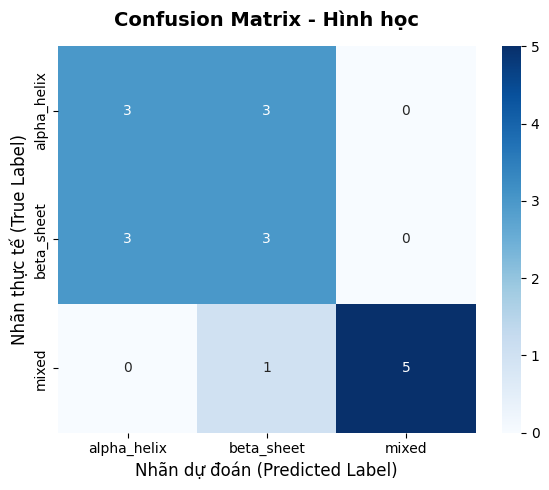

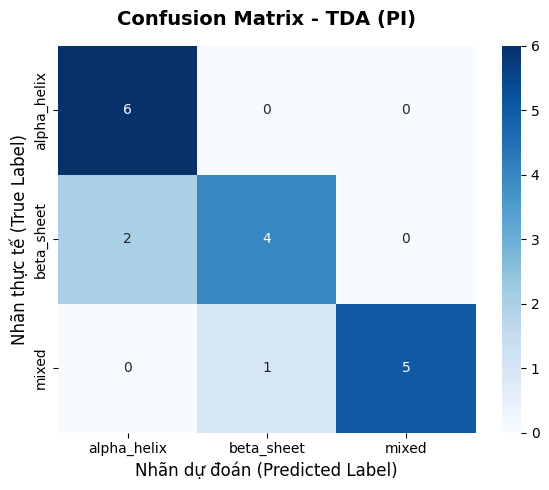

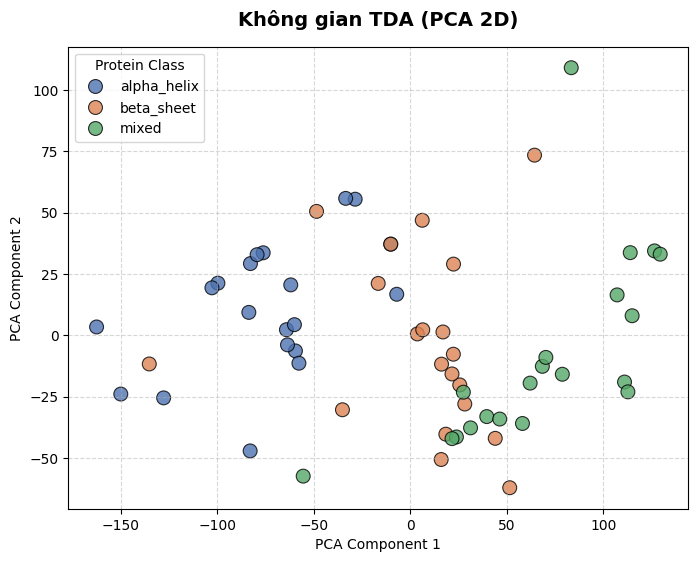

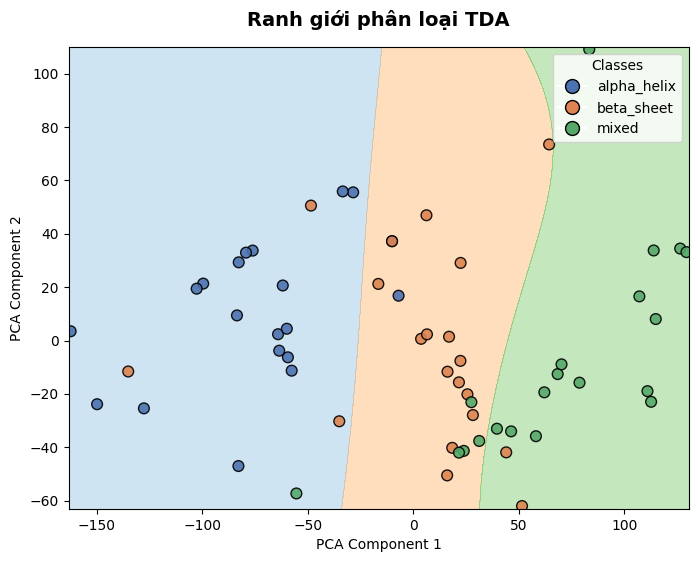

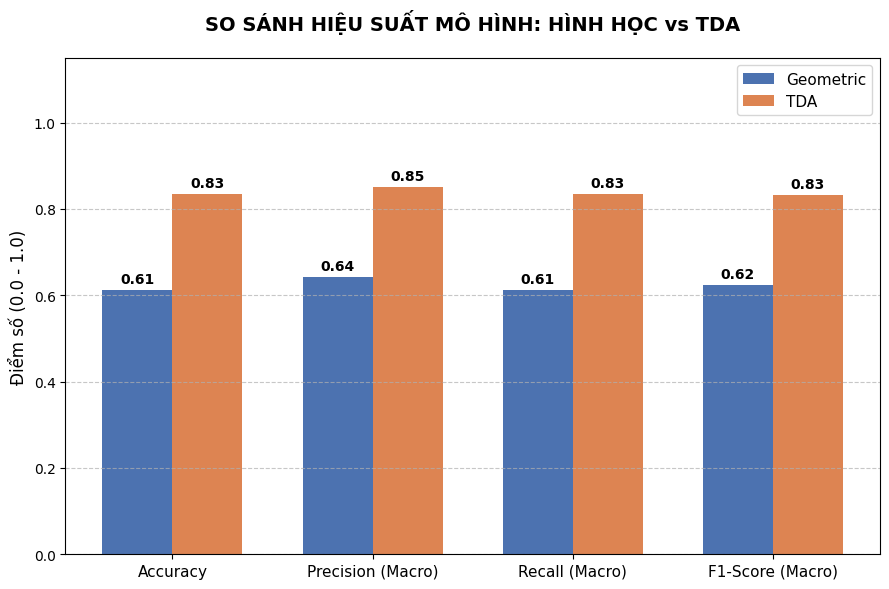

In [5]:
def load_dataset_for_model(filepath):
    data = np.load(filepath, allow_pickle=True)
    X = np.array([item["features"] for item in data])
    y = np.array([item["label"] for item in data])
    return X, y

class_names = ["alpha_helix", "beta_sheet", "mixed"]
le = LabelEncoder()
le.fit(class_names)

X_geo, y_geo_str = load_dataset_for_model(config.GEO_FEATURES_FILE)
y_geo = le.transform(y_geo_str)
svm_geo = SVMClassifier(**config.SVM_PARAMS, verbose=False)
metrics_geo = svm_geo.fit(X_geo, y_geo)

X_tda, y_tda_str = load_dataset_for_model(config.PIMAGE_FEATURES_FILE)
y_tda = le.transform(y_tda_str)
svm_tda = SVMClassifier(**config.SVM_PARAMS, verbose=False)
metrics_tda = svm_tda.fit(X_tda, y_tda)

plot_confusion_matrix(metrics_geo['confusion_matrix'], class_names, title='Confusion Matrix - Hình học')
plt.show()
plot_confusion_matrix(metrics_tda['confusion_matrix'], class_names, title='Confusion Matrix - TDA (PI)')
plt.show()

plot_feature_space(X_tda, y_tda, class_names, title="Không gian TDA (PCA 2D)")
plt.show()
plot_pca_decision_boundary(X_tda, y_tda, config.PARAMS, class_names, title="Ranh giới phân loại TDA")
plt.show()

plot_model_comparison(metrics_geo, metrics_tda, "Geometric", "TDA")
plt.show()